首先下载yahoo的接口,获取国际金价

In [9]:
#pip install  yfinance

[黄金期货价格选择方法论详见](../../doc/紫金矿业预测与黄金期货价格选择.md)

In [1]:
import yfinance as yf
import pandas as pd
from pandas import DataFrame as df

紫金矿业A股上市时间是08年4月30日,H股上市时间是03年12月31日.  
市值方面,在A股流通6464.8亿,H股1020.6亿(2027/7/24日数据),价格A股流动性更好,相差11.64%.鉴于我买的是A股,且A股的散户紫金矿业最多,因此更有研判的价值,看看是否能用数据找出可能的趋势.

In [11]:
# gold_future=yf.download('gc=f',start='2008-05-01',end='2026-7-23')
# gold_future.to_csv('../../data/gold_future.csv')

In [23]:
gold_future=pd.read_csv('../../data/gold_future.csv')
gold_future.head(5)

,Price,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2008-05-01,848.9000244140625,873.5,849.5999755859375,855.0,28
3,2008-05-02,856.0999755859375,857.7000122070312,853.2999877929688,853.2999877929688,6
4,2008-05-05,872.2999877929688,872.7999877929688,861.2000122070312,861.2000122070312,35


可以看到,源文件的前两行是不需要的,我们删除前两行

In [24]:
gold_future = gold_future.drop(gold_future.index[[0,1]])

In [25]:
gold_future.head()

,Price,Close,High,Low,Open,Volume
2,2008-05-01,848.9000244140625,873.5,849.5999755859375,855.0,28
3,2008-05-02,856.0999755859375,857.7000122070312,853.2999877929688,853.2999877929688,6
4,2008-05-05,872.2999877929688,872.7999877929688,861.2000122070312,861.2000122070312,35
5,2008-05-06,876.0,881.4000244140625,872.2999877929688,872.2999877929688,47
6,2008-05-07,869.5999755859375,869.4000244140625,864.7999877929688,868.0,43


应该把Price改成Date,并且将其转换成dataframe的时间,作为索引.此外把开盘价和收盘价放在最前面,调整一下顺序

In [26]:
gold_future.rename(columns={"Price":"Date"},inplace=True)
gold_future.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [27]:
gold_future = gold_future[["Date","Open","Close","High","Low",'Volume']]
gold_future.head()

,Date,Open,Close,High,Low,Volume
2,2008-05-01,855.0,848.9000244140625,873.5,849.5999755859375,28
3,2008-05-02,853.2999877929688,856.0999755859375,857.7000122070312,853.2999877929688,6
4,2008-05-05,861.2000122070312,872.2999877929688,872.7999877929688,861.2000122070312,35
5,2008-05-06,872.2999877929688,876.0,881.4000244140625,872.2999877929688,47
6,2008-05-07,868.0,869.5999755859375,869.4000244140625,864.7999877929688,43


In [28]:
# gold_future['Date'] = pd.to_datetime(gold_future['Date'])
gold_future.head()

,Date,Open,Close,High,Low,Volume
2,2008-05-01,855.0,848.9000244140625,873.5,849.5999755859375,28
3,2008-05-02,853.2999877929688,856.0999755859375,857.7000122070312,853.2999877929688,6
4,2008-05-05,861.2000122070312,872.2999877929688,872.7999877929688,861.2000122070312,35
5,2008-05-06,872.2999877929688,876.0,881.4000244140625,872.2999877929688,47
6,2008-05-07,868.0,869.5999755859375,869.4000244140625,864.7999877929688,43


In [29]:
gold_future.set_index('Date',inplace=True)

In [30]:
gold_future.head()

,Open,Close,High,Low,Volume
Date,,,,,
2008-05-01,855.0,848.9000244140625,873.5,849.5999755859375,28
2008-05-02,853.2999877929688,856.0999755859375,857.7000122070312,853.2999877929688,6
2008-05-05,861.2000122070312,872.2999877929688,872.7999877929688,861.2000122070312,35
2008-05-06,872.2999877929688,876.0,881.4000244140625,872.2999877929688,47
2008-05-07,868.0,869.5999755859375,869.4000244140625,864.7999877929688,43


In [31]:
gold_future = gold_future.round(2)

In [32]:
gold_future.head()

,Open,Close,High,Low,Volume
Date,,,,,
2008-05-01,855.0,848.9000244140625,873.5,849.5999755859375,28
2008-05-02,853.2999877929688,856.0999755859375,857.7000122070312,853.2999877929688,6
2008-05-05,861.2000122070312,872.2999877929688,872.7999877929688,861.2000122070312,35
2008-05-06,872.2999877929688,876.0,881.4000244140625,872.2999877929688,47
2008-05-07,868.0,869.5999755859375,869.4000244140625,864.7999877929688,43


这里为什么取两位小数没有反应?检查一下数据类型

In [33]:
gold_future.dtypes

Open      object
Close     object
High      object
Low       object
Volume    object
dtype: object

原因是数据读取时为字符串,转成float类型

In [34]:
# gold_future = gold_future[['Date','Open','Close','High','Low','Volume']]
gold_future = gold_future[['Open','Close','High','Low','Volume']].apply(pd.to_numeric)
gold_future.dtypes

Open      float64
Close     float64
High      float64
Low       float64
Volume      int64
dtype: object

In [35]:
gold_future.head()

,Open,Close,High,Low,Volume
Date,,,,,
2008-05-01,855.000000,848.900024,873.500000,849.599976,28
2008-05-02,853.299988,856.099976,857.700012,853.299988,6
2008-05-05,861.200012,872.299988,872.799988,861.200012,35
2008-05-06,872.299988,876.000000,881.400024,872.299988,47
2008-05-07,868.000000,869.599976,869.400024,864.799988,43


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

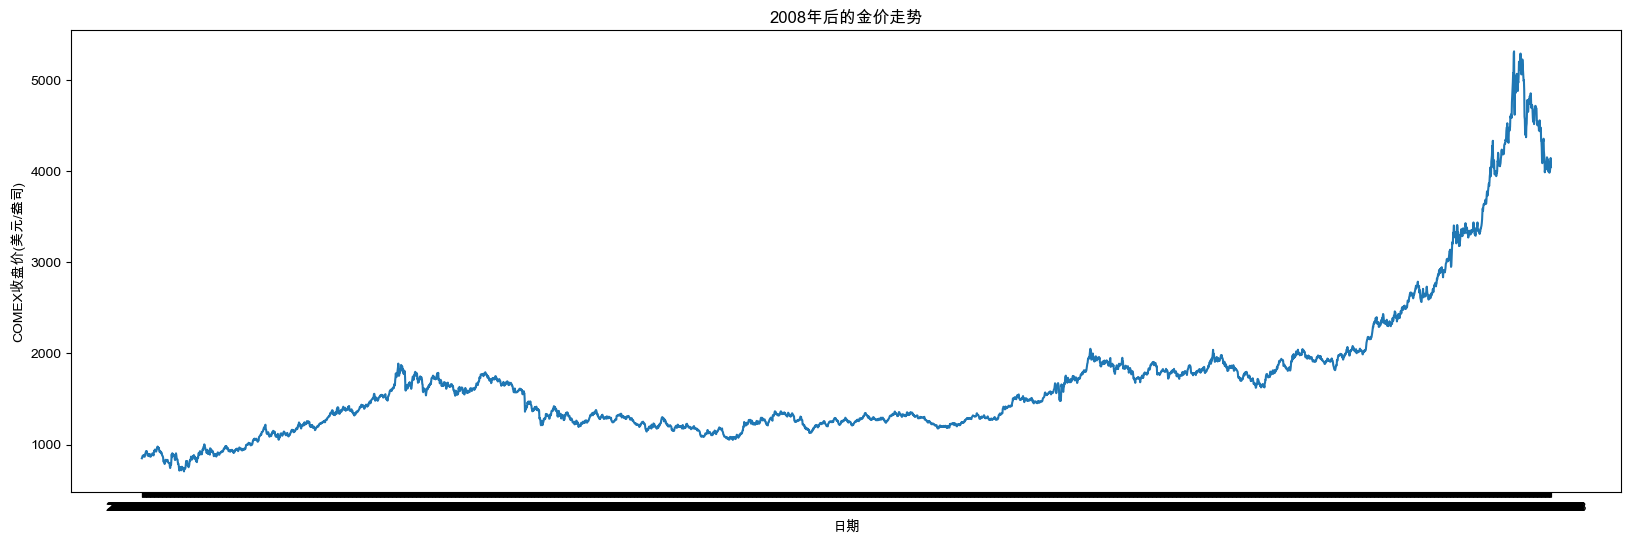

In [36]:
plt.figure(figsize=(20,6))
sns.lineplot(gold_future['Close'],)
plt.title('2008年后的金价走势')
plt.xlabel('日期')
plt.ylabel('COMEX收盘价(美元/盎司)')
plt.rcParams['font.sans-serif'] = ["Arial Unicode MS"]

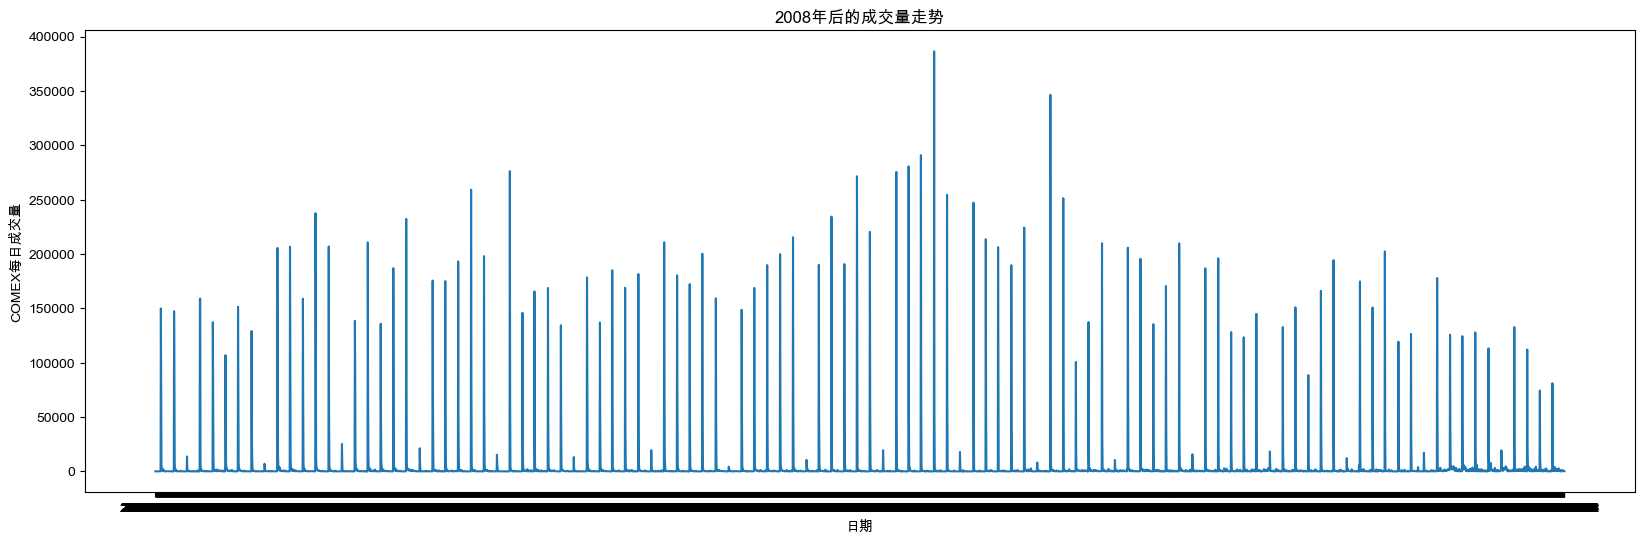

In [37]:
plt.figure(figsize=(20,6))
sns.lineplot(gold_future['Volume'],)
plt.title('2008年后的成交量走势')
plt.xlabel('日期')
plt.ylabel('COMEX每日成交量')
plt.rcParams['font.sans-serif'] = ["Arial Unicode MS"]

In [17]:
gold_future['Volume'].describe()

count      4584.000000
mean       5168.561955
std       27428.627725
min           0.000000
25%          50.750000
50%         181.000000
75%         586.250000
max      386334.000000
Name: Volume, dtype: float64

从图中和数据描述中来看,交易量的变动是非常大的,月与月之间的成交量之间也相差较大,但是数量级比天和周要小很多,以月来计算

In [ ]:
gold_future_volume_monthly = gold_future['Volume'].resample("M").sum()
gold_future_volume_monthly

/var/folders/nm/mph7gkl57w5_rd8w9fgp9c5r0000gp/T/ipykernel_29236/1793540987.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  gold_future_volume_monthly = gold_future['Volume'].resample("M").sum()


Date
2008-05-31    221793
2008-06-30      9462
2008-07-31    250477
2008-08-31      9253
2008-09-30     18800
               ...  
2026-03-31    105337
2026-04-30     14620
2026-05-31    105107
2026-06-30     26398
2026-07-31      6640
Freq: ME, Name: Volume, Length: 219, dtype: int64

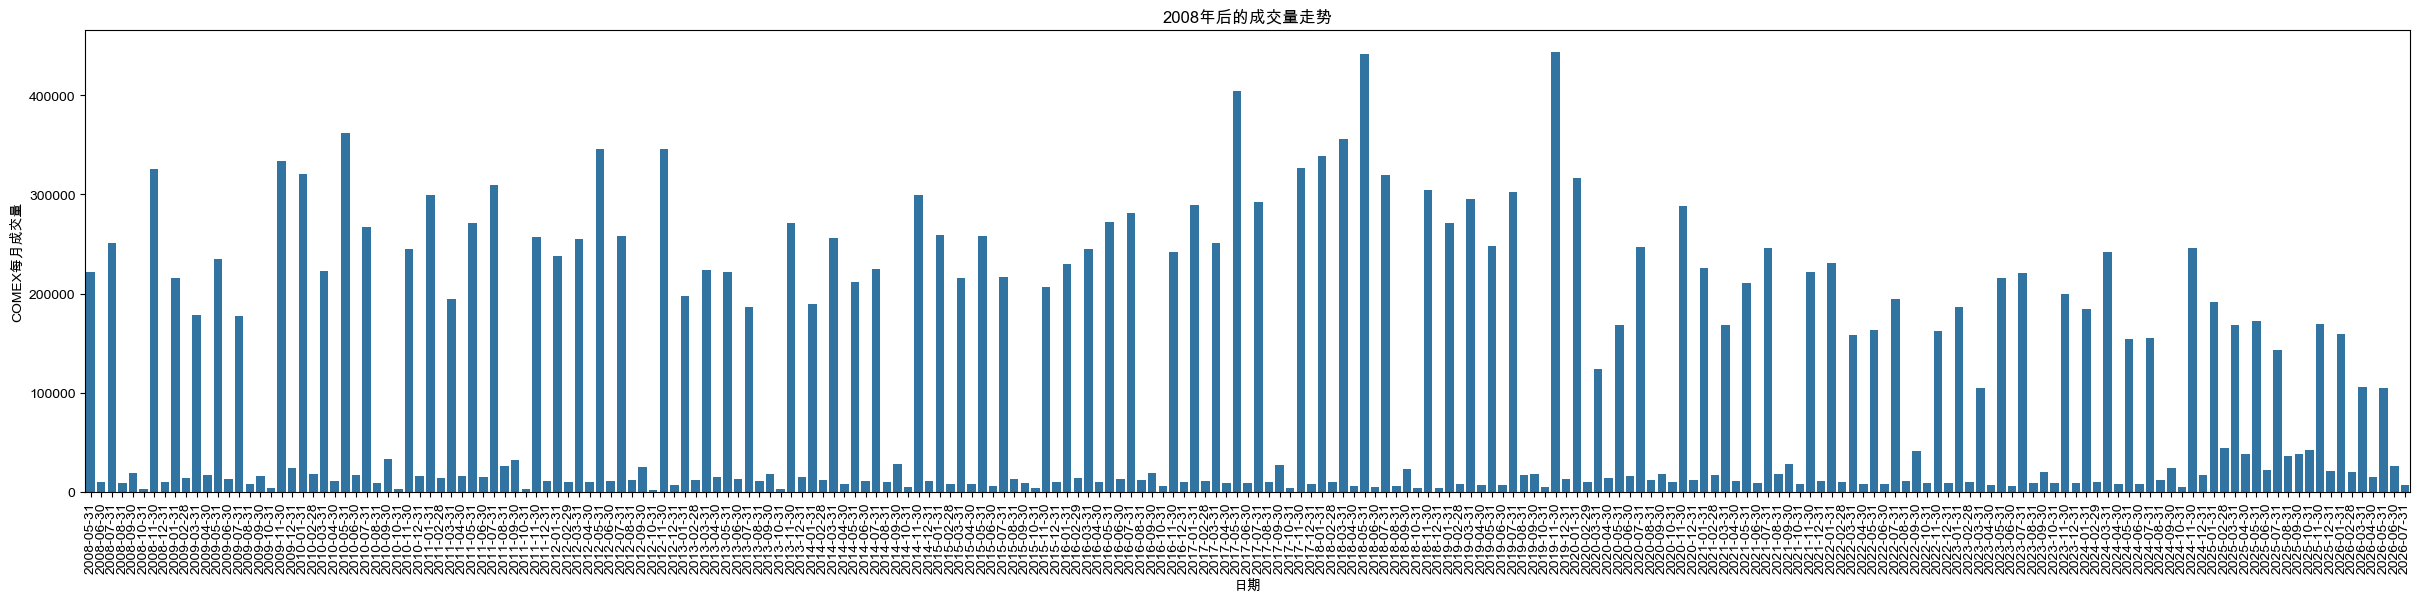

In [ ]:
plt.figure(figsize=(30,6))
plt.xticks(rotation=90)
sns.barplot(gold_future_volume_monthly)
plt.title('2008年后的成交量走势')
plt.xlabel('日期')
plt.ylabel('COMEX每月成交量')
plt.rcParams['font.sans-serif'] = ["Arial Unicode MS"]


查了下原始数据,以月为单位的期货量确实会出现一个月大,一个月小的情况,这是什么原因导致的?
由于期货的性质,存在着主力合约和换月移仓的机制,期货合约需要在前一个月交割,因此大部分人会退出,参加下一个主力合约,造成了合约的交易量呈现这样大小交替的规律.据观察,一般成交量都在月底放量.
根据交易所设计,希望能让价格平稳,交易集中在某几个月份,以提高流动性和价格的稳定性.大部分持仓人与基金参与者会在进入实物交割前进行调仓,进入下个合约.

## 由于合约的性质,每个月的交易量波动如果用于判断金价和股票价格,由于移仓行为的存在只能作为噪音.需要进行处理后再使用.可以进行平滑处理之后再使用,暂时未想出处理的办法.  
### 并且还要面临突如其来的外部冲击,以过去历史无事发生的测算结果必然有一定偏差  
但是成交量只能作为市场对某一商品的价格可能变动的参与程度,对决定价值和价格的供求关系理论上不应该存在影响,之后需要分别对比,将成交量处理以后,作为一个特征,比对两者在不同模型下的预测准确率.  
但是市场行为又受到了情绪的影响,价格会偏离价值,短期的成交量,也许会对价格变动的趋势有一定的放大作用.在统计上有可能有意义.  
在长期预测中,可能应该剔除,但是在短期的价格预测方面,如几个月的行情中,会是趋势的放大器.也许应该在处理时,将范围缩小一点,强化最新一个月的权重.

In [40]:
gold_future.index = pd.to_datetime(gold_future.index)
gold_future = gold_future[gold_future.index >= '2012-05-09']
gold_future

,Open,Close,High,Low,Volume
Date,,,,,
2012-05-09,1595.300049,1593.699951,1595.300049,1586.300049,30
2012-05-10,1594.199951,1595.099976,1595.099976,1592.400024,6
2012-05-11,1586.099976,1583.599976,1589.599976,1583.599976,6
2012-05-14,1563.000000,1560.599976,1563.099976,1555.500000,5
2012-05-15,1555.400024,1556.800049,1558.300049,1542.400024,28
...,...,...,...,...,...
2026-07-17,3975.500000,4012.699951,4017.199951,3964.199951,141
2026-07-20,4003.399902,4010.300049,4018.899902,4002.699951,231
2026-07-21,4002.100098,4071.100098,4071.100098,3999.699951,87


In [41]:
gold_future.to_pickle('../../src/pickle/gold_future.pkl')